In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import xarray as xr
from klepto.archives import file_archive
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import numpy.ma as ma

In [2]:
# open snapshot, std (standart deviation) and mean of Basilisk sealevel
ds_level = xr.open_dataset("data/NA_isopycs_mean.nc", decode_times=False, chunks={"time": 10})
ssh = ds_level["h"][-1]
ds_std = xr.open_dataset("data/NA_isopycs_std.nc", decode_times=False, chunks={"time": 10})
ssh_std = ds_std["h"][-1]
lat_mod = ssh.y
lon_mod = ssh.x
ds_snap = xr.open_dataset("data/NA_ssh_snap.nc")
ssh_snap = ds_snap["isopycs"]

# std of sea level from aviso. (Large Dataset, cannot be provided online. For access, the open research section of the article can be consulted.)
adt_mean = xr.open_dataset("data/AVISO_mean.nc", decode_times=False)["adt"]
adt_std = xr.open_dataset("data/AVISO_std.nc", decode_times=False)["adt"]
adt_snap = xr.open_dataset("data/AVISO_snap.nc", decode_times=False)["adt"]
lat_obs = adt_std.latitude
lon_obs = adt_std.longitude
lat_mdt = adt_std.latitude
lon_mdt = adt_std.longitude

In [3]:
# topo mask 
ds_topo = xr.open_dataset("data/topo.nc")
topo = ds_topo["zb"][0,0,:,:]
mask = topo < 0
mx = ma.masked_array(np.zeros(np.shape(topo)), mask=mask)

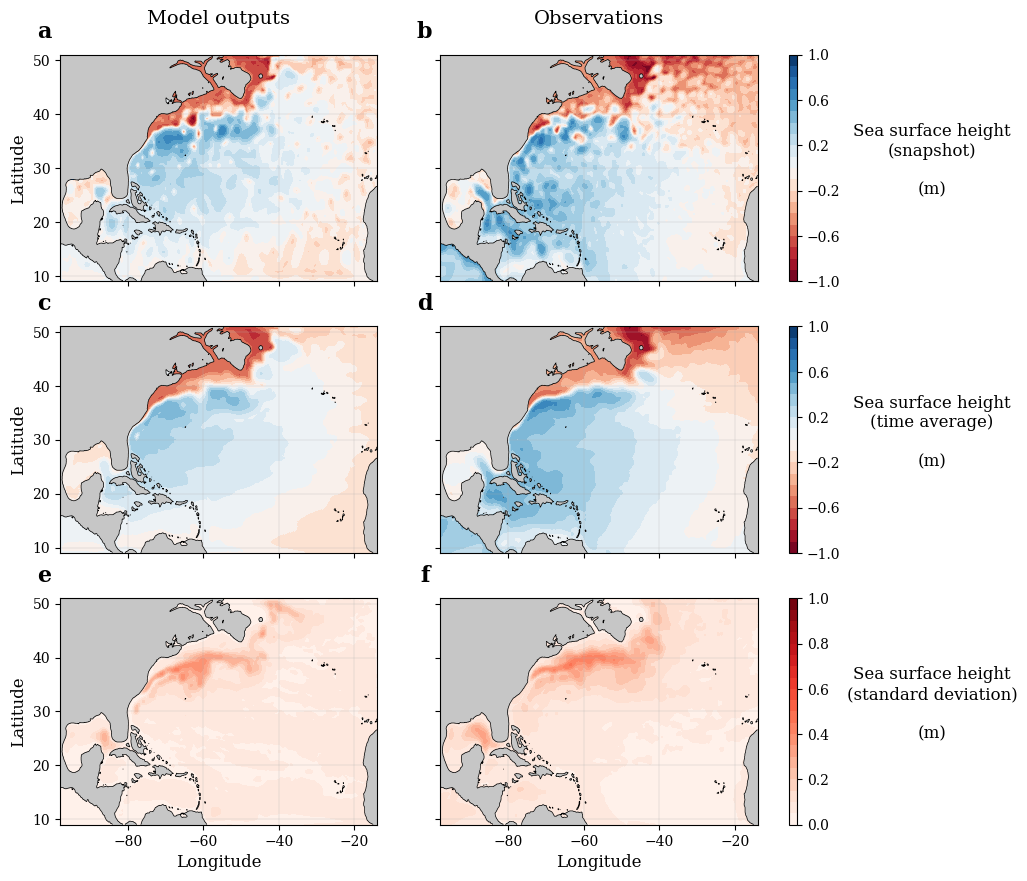

In [6]:
plt.rcParams['font.family'] = 'serif'

fig = plt.figure(figsize=(9, 10))
grid = plt.GridSpec(3, 2, hspace=0.2, wspace=0.2)

cmap = "RdBu"
levels = np.linspace(-1, 1, 21)

# ssh snapshots
v = 1

axes = fig.add_subplot(grid[0,0])
axes.set_title("Model outputs", size = 14, y = 1.1)
axes.pcolormesh(lon_mod, lat_mod, ssh_snap - ssh.mean().values, vmin = -v, vmax = v, cmap = cmap)
cplot = axes.contourf(lon_mod, lat_mod, ssh_snap - ssh.mean().values, vmin = -v, vmax = v, cmap = cmap, levels = levels)
axes.pcolormesh(lon_mod, lat_mod, mx, cmap = "Grays", vmin = -1, vmax = 2, zorder = 2)
axes.contour(lon_mod, lat_mod, topo, levels = [0], colors = "k", linewidths = 0.5)
axes.set_ylabel("Latitude", size = 12)
axes.set_xticklabels([])

# add grid
axes.grid(zorder = 1, linewidth = 0.2)

# add label
axes.text(-0.05, 1.1, "a", weight = "bold", horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 16)

axes = fig.add_subplot(grid[0,1])
axes.set_title("Observations", size = 14, y = 1.1)
axes.pcolormesh(lon_obs, lat_obs, adt_snap - adt_mean.mean().values, vmin = -v, vmax = v, cmap = cmap)
cplot = axes.contourf(lon_obs, lat_obs, adt_snap - adt_mean.mean().values, vmin = -v, vmax = v, cmap = cmap, levels = levels)
axes.pcolormesh(lon_mod, lat_mod, mx, cmap = "Grays", vmin = -1, vmax = 2, zorder = 2)
axes.contour(lon_mod, lat_mod, topo, levels = [0], colors = "k", linewidths = 0.5)
axes.set_yticklabels([])
axes.set_xticklabels([])
axes.set_xlim([lon_mod[0], lon_mod[-1]])
axes.set_ylim([lat_mod[0], lat_mod[-1]])

divider = make_axes_locatable(axes)
cax = axes.inset_axes((1.1, 0,0.025, 1))

# add grid
axes.grid(zorder = 1, linewidth = 0.2)

# add label
axes.text(-0.05, 1.1, "b", weight = "bold", horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 16)

cbar = plt.colorbar(cplot, cax=cax, orientation='vertical', ticks = levels[::4])
#cbar.ax.set_yticklabels([r'$-2$',r'$-1$',r'$0$',r'$1$',r'$2$'])  # vertically oriented colorbar
cax.set_ylabel('Sea surface height\n' + '(snapshot)\n\n'+ r'(m)' , rotation = 0, size = 12)
cax.yaxis.set_label_coords(18,0.7)



# ssh mean
v = 1

axes = fig.add_subplot(grid[1,0])
axes.pcolormesh(lon_mod, lat_mod, ssh - ssh.mean().values, vmin = -v, vmax = v, cmap = cmap)
cplot = axes.contourf(lon_mod, lat_mod, ssh - ssh.mean().values, vmin = -v, vmax = v, cmap = cmap, levels = levels)
axes.pcolormesh(lon_mod, lat_mod, mx, cmap = "Grays", vmin = -1, vmax = 2, zorder = 2)
axes.contour(lon_mod, lat_mod, topo, levels = [0], colors = "k", linewidths = 0.5)
axes.set_ylabel("Latitude", size = 12)
axes.set_xticklabels([])

# add grid
axes.grid(zorder = 1, linewidth = 0.2)

# add label
axes.text(-0.05, 1.1, "c", weight = "bold", horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 16)

axes = fig.add_subplot(grid[1,1])
axes.pcolormesh(lon_obs, lat_obs, adt_mean - adt_mean.mean().values, vmin = -v, vmax = v, cmap = cmap)
cplot = axes.contourf(lon_obs, lat_obs, adt_mean - adt_mean.mean().values, vmin = -v, vmax = v, cmap = cmap, levels = levels)
axes.pcolormesh(lon_mod, lat_mod, mx, cmap = "Grays", vmin = -1, vmax = 2, zorder = 2)
axes.contour(lon_mod, lat_mod, topo, levels = [0], colors = "k", linewidths = 0.5)
axes.set_yticklabels([])
axes.set_xticklabels([])
axes.set_xlim([lon_mod[0], lon_mod[-1]])
axes.set_ylim([lat_mod[0], lat_mod[-1]])

divider = make_axes_locatable(axes)
cax = axes.inset_axes((1.1, 0,0.025, 1))

# add grid
axes.grid(zorder = 1, linewidth = 0.2)

# add label
axes.text(-0.05, 1.1, "d", weight = "bold", horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 16)

cbar = plt.colorbar(cplot, cax=cax, orientation='vertical', ticks = levels[::4])
#cbar.ax.set_yticklabels([r'$-2$',r'$-1$',r'$0$',r'$1$',r'$2$'])  # vertically oriented colorbar
cax.set_ylabel('Sea surface height\n' + '(time average)\n\n'+ r'(m)' , rotation = 0, size = 12)
cax.yaxis.set_label_coords(18,0.7)


# ssh std
v = 1
cmap = "Reds"
levels = np.linspace(0, 1, 21)


axes = fig.add_subplot(grid[2,0])
axes.pcolormesh(lon_mod, lat_mod, ssh_std, vmin = 0, vmax = v, cmap = cmap)
cplot = axes.contourf(lon_mod, lat_mod, ssh_std, vmin = 0, vmax = v, cmap = cmap, levels = levels)
axes.pcolormesh(lon_mod, lat_mod, mx, cmap = "Grays", vmin = -1, vmax = 2, zorder = 2)
axes.contour(lon_mod, lat_mod, topo, levels = [0], colors = "k", linewidths = 0.5)
axes.set_ylabel("Latitude", size = 12)
axes.set_xlabel("Longitude", size = 12)

# add grid
axes.grid(zorder = 1, linewidth = 0.2)

# add label
axes.text(-0.05, 1.1, "e", weight = "bold", horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 16)

axes = fig.add_subplot(grid[2,1])
axes.pcolormesh(lon_obs, lat_obs, adt_std, vmin = 0, vmax = v, cmap = cmap)
cplot = axes.contourf(lon_obs, lat_obs, adt_std, vmin = 0, vmax = v, cmap = cmap, levels = levels)
axes.pcolormesh(lon_mod, lat_mod, mx, cmap = "Grays", vmin = -1, vmax = 2, zorder = 2)
axes.contour(lon_mod, lat_mod, topo, levels = [0], colors = "k", linewidths = 0.5)
axes.set_yticklabels([])
axes.set_xlabel("Longitude", size = 12)
axes.set_xlim([lon_mod[0], lon_mod[-1]])
axes.set_ylim([lat_mod[0], lat_mod[-1]])

divider = make_axes_locatable(axes)
cax = axes.inset_axes((1.1, 0,0.025, 1))

# add grid
axes.grid(zorder = 1, linewidth = 0.2)

# add label
axes.text(-0.05, 1.1, "f", weight = "bold", horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 16)

cbar = plt.colorbar(cplot, cax=cax, orientation='vertical', ticks = levels[::4])
#cbar.ax.set_yticklabels([r'$-2$',r'$-1$',r'$0$',r'$1$',r'$2$'])  # vertically oriented colorbar
cax.set_ylabel('Sea surface height\n' + '(standard deviation)\n\n'+ r'(m)' , rotation = 0, size = 12)
cax.yaxis.set_label_coords(18,0.7)

plt.savefig('validation_AVISO.png', dpi = 400, bbox_inches='tight', format = 'png')